In [1]:
import json
from pathlib import Path

DATA_PATH = Path("../data/raw/new_delhi__2024-08-12_to_2024-08-12_.geojson")

with open(DATA_PATH, "r") as f:
    data = json.load(f)

print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['type', 'features'])


In [2]:
print("Number of features:", len(data["features"]))

Number of features: 24939


In [3]:
road = data["features"][1]

print(road.keys())
print(road["properties"].keys())
print(road["geometry"]["type"])

dict_keys(['type', 'geometry', 'properties'])
dict_keys(['segmentId', 'newSegmentId', 'speedLimit', 'frc', 'streetName', 'distance', 'segmentProbeCounts'])
LineString


In [4]:
print(road["properties"])

{'segmentId': -13560111507837, 'newSegmentId': '-00004e30-3400-0400-0000-0000008bad86', 'speedLimit': 45, 'frc': 6, 'streetName': 'Ghata Masjid Road', 'distance': 20.87, 'segmentProbeCounts': [{'timeSet': 2, 'dateRange': 1, 'probeCount': 1}, {'timeSet': 3, 'dateRange': 1, 'probeCount': 3}, {'timeSet': 4, 'dateRange': 1, 'probeCount': 2}, {'timeSet': 5, 'dateRange': 1, 'probeCount': 0}, {'timeSet': 6, 'dateRange': 1, 'probeCount': 0}, {'timeSet': 7, 'dateRange': 1, 'probeCount': 2}, {'timeSet': 8, 'dateRange': 1, 'probeCount': 1}, {'timeSet': 9, 'dateRange': 1, 'probeCount': 2}, {'timeSet': 10, 'dateRange': 1, 'probeCount': 3}, {'timeSet': 11, 'dateRange': 1, 'probeCount': 8}, {'timeSet': 12, 'dateRange': 1, 'probeCount': 7}, {'timeSet': 13, 'dateRange': 1, 'probeCount': 8}, {'timeSet': 14, 'dateRange': 1, 'probeCount': 7}, {'timeSet': 15, 'dateRange': 1, 'probeCount': 8}, {'timeSet': 16, 'dateRange': 1, 'probeCount': 5}, {'timeSet': 17, 'dateRange': 1, 'probeCount': 5}, {'timeSet': 18,

In [5]:
properties = road["properties"]

print(properties["segmentProbeCounts"][:3])

[{'timeSet': 2, 'dateRange': 1, 'probeCount': 1}, {'timeSet': 3, 'dateRange': 1, 'probeCount': 3}, {'timeSet': 4, 'dateRange': 1, 'probeCount': 2}]


In [6]:
print(
    "Number of hourly observations:",
    len(properties["segmentProbeCounts"])
)

Number of hourly observations: 24


In [7]:
print("Segment ID:", properties.get("segmentId"))
print("Street:", properties.get("streetName"))
print("Speed limit:", properties.get("speedLimit"))
print("FRC:", properties.get("frc"))
print("Distance:", properties.get("distance"))

Segment ID: -13560111507837
Street: Ghata Masjid Road
Speed limit: 45
FRC: 6
Distance: 20.87


In [8]:
print("Geometry:", road["geometry"]["type"])
print("Coordinates:", road["geometry"]["coordinates"][:2])

Geometry: LineString
Coordinates: [[77.24376, 28.64596], [77.2437, 28.64601]]


## 2. Flatten Road-Level Hourly Traffic Data

Each road segment contains 24 hourly probe-count observations.
We will transform the nested GeoJSON structure into a tabular format
where each row represents one road segment at one hourly time point.

In [9]:
import pandas as pd

rows = []

for feature in data["features"]:
    properties = feature.get("properties", {})
    geometry = feature.get("geometry")

    # Skip the metadata feature
    if geometry is None:
        continue

    segment_id = properties.get("segmentId")
    new_segment_id = properties.get("newSegmentId")
    speed_limit = properties.get("speedLimit")
    frc = properties.get("frc")
    street_name = properties.get("streetName")
    distance = properties.get("distance")

    for observation in properties.get("segmentProbeCounts", []):
        rows.append({
            "segment_id": segment_id,
            "new_segment_id": new_segment_id,
            "speed_limit": speed_limit,
            "frc": frc,
            "street_name": street_name,
            "distance": distance,
            "time_set": observation.get("timeSet"),
            "probe_count": observation.get("probeCount")
        })

df = pd.DataFrame(rows)

print("Shape:", df.shape)
df.head()

Shape: (598512, 8)


,segment_id,new_segment_id,speed_limit,frc,street_name,distance,time_set,probe_count
0,-13560111507837,-00004e30-3400-0400-0000-0000008bad86,45,6,Ghata Masjid Road,20.87,2,1
1,-13560111507837,-00004e30-3400-0400-0000-0000008bad86,45,6,Ghata Masjid Road,20.87,3,3
2,-13560111507837,-00004e30-3400-0400-0000-0000008bad86,45,6,Ghata Masjid Road,20.87,4,2
3,-13560111507837,-00004e30-3400-0400-0000-0000008bad86,45,6,Ghata Masjid Road,20.87,5,0
4,-13560111507837,-00004e30-3400-0400-0000-0000008bad86,45,6,Ghata Masjid Road,20.87,6,0


In [11]:
print(df.columns.tolist())

['segment_id', 'new_segment_id', 'speed_limit', 'frc', 'street_name', 'distance', 'time_set', 'probe_count']


In [10]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 598512
Columns: 8


In [ ]:
## 3. Data Validation

Before analysis or machine learning, we validate the flattened dataset for:

- Missing values
- Duplicate rows
- Invalid values
- Hour/time coverage
- Zero probe counts
- Numeric data types

In [14]:
df.isnull().sum()

segment_id            0
new_segment_id        0
speed_limit           0
frc                   0
street_name       53496
distance              0
time_set              0
probe_count           0
dtype: int64

In [13]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
print("Unique time sets:", sorted(df["time_set"].unique()))

Unique time sets: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]


In [15]:
df["probe_count"].describe()


count    598512.000000
mean        110.463550
std         180.084788
min           0.000000
25%           7.000000
50%          38.000000
75%         130.000000
max        2223.000000
Name: probe_count, dtype: float64

In [16]:
zero_count = (df["probe_count"] == 0).sum()

print("Zero probe observations:", zero_count)
print("Zero percentage:", zero_count / len(df) * 100)


Zero probe observations: 48256
Zero percentage: 8.062662068596786


In [17]:
print("Negative probe counts:", (df["probe_count"] < 0).sum())

Negative probe counts: 0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598512 entries, 0 to 598511
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   segment_id      598512 non-null  int64  
 1   new_segment_id  598512 non-null  object 
 2   speed_limit     598512 non-null  int64  
 3   frc             598512 non-null  int64  
 4   street_name     545016 non-null  object 
 5   distance        598512 non-null  float64
 6   time_set        598512 non-null  int64  
 7   probe_count     598512 non-null  int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 36.5+ MB


In [19]:
observations_per_road = df.groupby("segment_id").size()

print(observations_per_road.value_counts().sort_index())

24    24938
Name: count, dtype: int64


In [20]:
missing = df.isnull().sum()

print(missing)

segment_id            0
new_segment_id        0
speed_limit           0
frc                   0
street_name       53496
distance              0
time_set              0
probe_count           0
dtype: int64


In [21]:
print("\nMissing percentage:")
print((df.isnull().mean() * 100).round(2))


Missing percentage:
segment_id        0.00
new_segment_id    0.00
speed_limit       0.00
frc               0.00
street_name       8.94
distance          0.00
time_set          0.00
probe_count       0.00
dtype: float64


In [22]:
zero_by_time = (
    df[df["probe_count"] == 0]
    .groupby("time_set")
    .size()
)

print(zero_by_time)

zero_percentage_by_time = (
    df.groupby("time_set")["probe_count"]
    .apply(lambda x: (x == 0).mean() * 100)
)

print("\nZero percentage by time:")
print(zero_percentage_by_time.round(2))

time_set
2     2954
3     3863
4     4758
5     5539
6     5387
7     4496
8     2640
9     1791
10    1338
11    1198
12    1093
13    1030
14     830
15     931
16    1002
17     966
18     879
19     840
20     856
21     856
22     959
23    1045
24    1356
25    1649
dtype: int64

Zero percentage by time:
time_set
2     11.85
3     15.49
4     19.08
5     22.21
6     21.60
7     18.03
8     10.59
9      7.18
10     5.37
11     4.80
12     4.38
13     4.13
14     3.33
15     3.73
16     4.02
17     3.87
18     3.52
19     3.37
20     3.43
21     3.43
22     3.85
23     4.19
24     5.44
25     6.61
Name: probe_count, dtype: float64


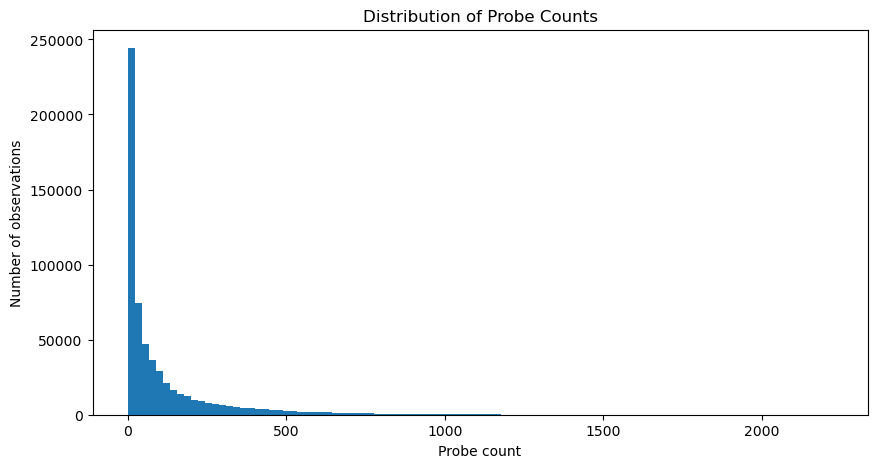

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df["probe_count"], bins=100)
plt.xlabel("Probe count")
plt.ylabel("Number of observations")
plt.title("Distribution of Probe Counts")
plt.show()